# 8. Fermionic swap network

This notebook demonstrates the fermionic swap network for approximating the time evolution operator governed by a spinless Fermi-Hubbard-type Hamiltonian with long-range interactions, of the form
\begin{equation*}
H = \sum_{j \neq k}^{L-1} t_{jk} a_j^{\dagger} a_k + \sum_{j < k}^{L-1} v_{jk} n_j n_k
\end{equation*}
with a symmetric coefficient matrix $t \in \mathbb{R}^{L \times L}$ and an upper triangular coefficient matrix $v \in \mathbb{R}^{L \times L}$.

Reference:
- Ian D. Kivlichan, Jarrod McClean, Nathan Wiebe, Craig Gidney, Alán Aspuru-Guzik, Garnet Kin-Lic Chan, Ryan Babbush  
  Quantum simulation of electronic structure with linear depth and connectivity  
  [Phys. Rev. Lett. 120, 110501 (2018)](https://doi.org/10.1103/PhysRevLett.120.110501)

Simulating fermionic systems on a (digital, qubit-based) quantum computer generically requires a mapping of the fermionic operators to qubits. A straightforward method is the Jordan-Wigner transformation, which, however, potentially introduces long-range Pauli-$Z$ strings between pairs of fermionic operators. The central idea of the swap network architecture is to apply "swaps" to the fermionic modes such that any pair is a direct neighbor at some point (and does not require a $Z$-string). During that instance, one applies the Trotterized time-evolution gate corresponding to the interaction in the Hamiltonian for this pair. The following picture is taken from the cited publication and visualizes the idea:

<img src="swap_network.png" alt="Swap network. Source: Phys. Rev. Lett. 120, 110501 (2018)" width="480"/>

As an illustration, let's construct the matrix representation of a fermionic "swap" applied to two neighboring modes, see Eq. (2) in the cited paper. The computational basis consists of the binary occupation patterns
\begin{equation*}
\{ \ket{{\large\circ}{\large\circ}}, \ket{{\large\circ}{\large\bullet}}, \ket{{\large\bullet}{\large\circ}}, \ket{{\large\bullet}{\large\bullet}} \}.
\end{equation*}

In [1]:
import fermi_relations as fr
import numpy as np
from scipy import sparse

In [2]:
# Eq. (2) in Phys. Rev. Lett. 120, 110501 (2018)
clist2, alist2, nlist2 = fr.construct_fermionic_operators(2)
f_swap = sparse.identity(4) + clist2[0] @ alist2[1] + clist2[1] @ alist2[0] - nlist2[0] - nlist2[1]
f_swap.todense()

matrix([[ 1.,  0.,  0.,  0.],
        [ 0.,  0.,  1.,  0.],
        [ 0.,  1.,  0.,  0.],
        [ 0.,  0.,  0., -1.]])

The inner $2 \times 2$ block swaps $\ket{{\large\circ}{\large\bullet}} \leftrightarrow \ket{{\large\bullet}{\large\circ}}$, as expected. The $(-1)$ factor in the lower-right corner arises from the fermionic anticommuting property (when both modes are occupied).

To implement Trotterized time evolution, a local gate in the swap network consists of a swap, a kinetic hopping matrix exponential, and an interaction exponential; see Eqs. (4) and (5) in the paper. This results in the matrix:

In [3]:
def fermionic_simulation_matrix(tkin: float, vint: float, t: float):
    """
    Construct the matrix representation of the fermionic simulation gate.
    """
    c = np.cos(tkin * t)
    s = np.sin(tkin * t)
    v = np.exp(-1j * vint * t)
    return np.array([
        [1,   0,    0,    0],
        [0, -1j*s,  c,    0],
        [0,   c,  -1j*s,  0],
        [0,   0,    0,   -v],
    ])

In [4]:
from scipy.linalg import expm

# evolution time
t = 0.25

# verify that the fermionic simulation matrix indeed consists of
# a swap, a kinetic hopping matrix exponential, and an interaction exponential
np.linalg.norm(
    expm(-1j * 0.8 * t * (nlist2[0] @ nlist2[1]).todense()) @
    expm(-1j * 0.7 * t * (clist2[0] @ alist2[1] + clist2[1] @ alist2[0]).todense()) @
    f_swap
    - fermionic_simulation_matrix(0.7, 0.8, t))

np.float64(3.925231146709438e-17)

We now construct the above Hamiltonian as a sparse matrix and the corresponding time-evolution operator as a reference.

In [5]:
import scipy.sparse.linalg as spla

In [6]:
def construct_fermionic_hamiltonian(tkin, vint):
    """
    Construct a spinless Fermi-Hubbard-type Hamiltonian
    with long-range interactions as a sparse matrix.
    """
    tkin = np.asarray(tkin)
    vint = np.asarray(vint)
    nmodes = tkin.shape[0]
    assert tkin.shape == (nmodes, nmodes)
    assert vint.shape == (nmodes, nmodes)
    clist, alist, nlist = fr.construct_fermionic_operators(nmodes)
    # kinetic hopping and interaction terms
    hamiltonian = \
        sum(tkin[i, j] * (clist[i] @ alist[j])
            for i in range(nmodes)
            for j in range(nmodes)) + \
        sum(vint[i, j] * (nlist[i] @ nlist[j])
            for i in range(nmodes)
            for j in range(i + 1, nmodes))  # i < j
    hamiltonian.eliminate_zeros()
    return hamiltonian

In [7]:
# random number generator
rng = np.random.default_rng(49)

In [8]:
# number of modes
nmodes = 5

# random Hamiltonian coefficients
tkin = rng.standard_normal((nmodes, nmodes))
tkin = 0.5*(tkin + tkin.conj().T)
for j in range(nmodes):
    tkin[j, j] = 0
vint = np.triu(rng.standard_normal((nmodes, nmodes)), 1)

# Hamiltonian on the whole Fock space
hfock = construct_fermionic_hamiltonian(tkin, vint)
# must be Hermitian
assert spla.norm(hfock - hfock.conj().T) < 1e-13
# dimension scales as 2^L
print("hfock.shape:", hfock.shape)

# reference time evolution operator
expih = expm(-1j * t * hfock.toarray())

hfock.shape: (32, 32)


Next, we define a generic two-qubit gate and methods to find its matrix representation in the overall many-qubit space.

In [9]:
def permute_operation(u: np.ndarray, perm):
    """
    Matrix representation of an operation after permuting qubits.
    """
    nqubits = len(perm)
    assert u.shape == (2**nqubits, 2**nqubits)
    perm = list(perm)
    u = np.reshape(u, (2*nqubits) * (2,))
    u = np.transpose(u, perm + [nqubits + p for p in perm])
    u = np.reshape(u, (2**nqubits, 2**nqubits))
    return u

In [10]:
class TwoQubitGate:
    """
    Quantum gate acting on two qubits.
    """
    def __init__(self, mat, i: int, j: int):
        assert 0 <= i < j
        self.mat = np.asarray(mat)
        assert self.mat.shape == (4, 4)
        self.i = i
        self.j = j

    def to_circuit_unitary(self, nqubits: int):
        """
        Construct the unitary matrix representation
        of the gate embedded in a quantum circuit.
        """
        assert self.i < nqubits and self.j < nqubits
        u = np.kron(self.mat, np.identity(2**(nqubits - 2)))
        perm = (list(range(2, self.i + 2))
              + [0]
              + list(range(self.i + 2, self.j + 1))
              + [1]
              + list(range(self.j + 1, nqubits)))
        return permute_operation(u, perm)

In [11]:
def circuit_unitary(gates, nqubits: int):
    """
    Construct the overall unitary matrix representation of a
    quantum circuit consisting of a sequence of gates.
    """
    u = np.identity(2**nqubits)
    for gate in gates:
        u = gate.to_circuit_unitary(nqubits) @ u
    return u

The following functions implement the actual swap network.

In [12]:
def _fsim_gate_order(tkin, vint, i, j, t, order):
    """
    Construct the fermionic simulation gate for sites `i` and `j`
    and the provided mode order, and update the order based on the swap.
    """
    ip = order[i]
    jp = order[j]
    # swap
    order[j] = ip
    order[i] = jp
    return (TwoQubitGate(
        fermionic_simulation_matrix(
            tkin[ip, jp], vint[ip, jp], t), i, j),
        order)


def construct_fermionic_swapnet(tkin, vint, dt: float):
    """
    Construct the fermionic swap network approximation of the time evolution operator
    of a spinless Fermi-Hubbard-type Hamiltonian with long-range interactions.

    Reference:
        Ian D. Kivlichan, Jarrod McClean, Nathan Wiebe, Craig Gidney, Alán Aspuru-Guzik,
        Garnet Kin-Lic Chan, Ryan Babbush:
        Quantum simulation of electronic structure with linear depth and connectivity
        Phys. Rev. Lett. 120, 110501 (2018)
    """
    tkin = np.asarray(tkin)
    vint = np.asarray(vint)
    nmodes = tkin.shape[0]
    assert tkin.shape == (nmodes, nmodes)
    assert vint.shape == (nmodes, nmodes)
    gates = []
    order = list(range(nmodes))
    for l in range(nmodes):
        for i in range(l % 2, nmodes - 1, 2):
            gate, order = _fsim_gate_order(tkin, vint, i, i + 1, dt/2, order)
            gates.append(gate)
    assert order == list(reversed(range(nmodes)))
    # append same gates in reversed order to form a Strang step
    gates = gates + list(reversed(gates))
    return gates

We demonstrate and test the functionality via a convergence plot.

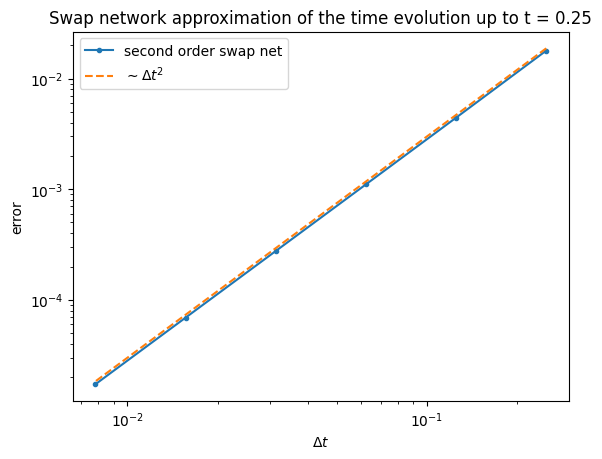

In [13]:
import matplotlib.pyplot as plt

# real-time evolution via Strang splitting for different time steps
nsteps_list = np.array([2**i for i in range(6)])
err = np.zeros(len(nsteps_list))
for i, nsteps in enumerate(nsteps_list):
    dt = t / nsteps
    gates = construct_fermionic_swapnet(tkin, vint, dt)
    cu = circuit_unitary(gates, nmodes)
    cun = np.linalg.matrix_power(cu, nsteps)
    err[i] = np.linalg.norm(cun - expih, ord=2)
# convergence plot
dt_list = t / nsteps_list
plt.loglog(dt_list, err, '.-', label="second order swap net")
plt.loglog(dt_list, 0.3*dt_list**2, '--', label=r"$\sim \Delta t^2$")
plt.xlabel(r"$\Delta t$")
plt.ylabel("error")
plt.legend()
plt.title(f"Swap network approximation of the time evolution up to t = {t}")
plt.show()